In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'

from joblib import Parallel, delayed

from scipy.special import iv

import pickle

import schwingerModel as sim

from scipy.optimize import curve_fit

In [4]:
with open('50kSteps.pkl', 'rb') as f:
    a1 = pickle.load(f)

with open('25kSteps_a_0.5.pkl', 'rb') as f:
    a5 = pickle.load(f)

with open('50kSteps_a_0.25.pkl', 'rb') as f:
    a25 = pickle.load(f)

In [5]:
bIn = 500
skp = 500
ti=1

gamma = np.array([[1j,0],[0,-1j]])

correl_a1 =  sim.correlation.GEVPStats(a1, burnIn=bIn,autocorrSkip=skp,Gamma=gamma,smearN1=4,kappa1=1.2,ti=ti,momk=0,hiMass=False)
correl_a5 =  sim.correlation.GEVPStats(a5, burnIn=bIn,autocorrSkip=skp,Gamma=gamma,smearN1=4,kappa1=1.2,ti=ti,momk=0,hiMass=False)
correl_a25 = sim.correlation.GEVPStats(a25, burnIn=bIn,autocorrSkip=skp,Gamma=gamma,smearN1=4,kappa1=1.2,ti=ti,momk=0,hiMass=False)

100%|██████████| 99/99 [00:40<00:00,  2.46it/s]


In [13]:
mass_a1 = sim.correlation.gevpMassExtract(correl_a1,fitT=31)
mass_a5 = sim.correlation.gevpMassExtract(correl_a5,fitT=31)
mass_a25 = sim.correlation.gevpMassExtract(correl_a25,fitT=31)

Text(0, 0.5, 'm')

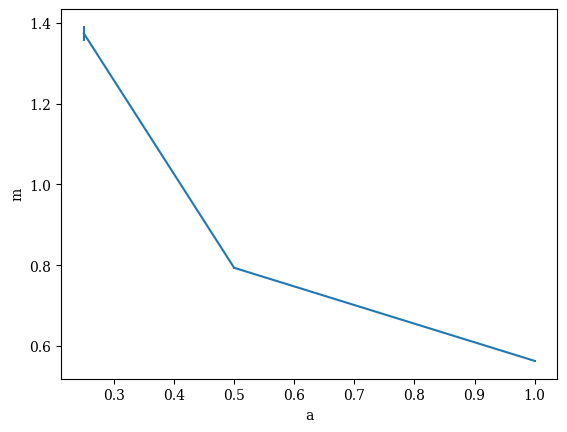

In [15]:
plt.errorbar(x=[.25,.5,1],y=[mass_a25[0]/a25.a,mass_a5[0]/a5.a,mass_a1[0]/a1.a],yerr=[mass_a25[1]/a25.a,mass_a5[1]/a5.a,mass_a1[1]/a1.a])
plt.xlabel("a")
plt.ylabel("m")